In [42]:
import os
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from inspect_ai.log import read_eval_log
from typing import Dict, Tuple, List
from sentence_transformers import SentenceTransformer
from umap import UMAP
import plotly.express as px

def load_eval_log(log_path: str):
    """
    Load the evaluation log from the specified path.

    Args:
        log_path: Path to the .eval log file.

    Returns:
        The loaded log object.

    Raises:
        FileNotFoundError: If the log path does not exist.
    """
    if not os.path.exists(log_path):
        raise FileNotFoundError(f"Log file not found at: {log_path}")
    return read_eval_log(log_path)


def compute_name_scores(log) -> Tuple[Dict[str, float], Dict[str, object]]:
    """
    Compute maximum final_scorer value for each name and track the highest-scoring sample.

    Args:
        log: The loaded evaluation log object.

    Returns:
        A tuple of two dictionaries:
            - name_to_max_score (name -> highest final_scorer value).
            - name_to_max_score_sample (name -> sample with the highest final_scorer).
    """
    name_to_max_score = {}
    name_to_max_score_sample = {}

    for sample in log.samples:
        name = sample.metadata["attributes"]["name"]
        score = sample.scores["final_scorer"].value
        current_max = name_to_max_score.get(name, 0.0)

        if score > current_max:
            name_to_max_score[name] = score
            name_to_max_score_sample[name] = sample

    return name_to_max_score, name_to_max_score_sample


def filter_top_samples(log) -> List[object]:
    """
    Pick the highest-scoring sample for each name.

    Args:
        log: The loaded evaluation log object.

    Returns:
        A list of the highest-scoring samples, one per unique name.
    """
    _, name_to_max_score_sample = compute_name_scores(log)
    return list(name_to_max_score_sample.values())


def filter_above_threshold(samples: List[object], threshold: float = 0.6) -> List[object]:
    """
    Filter out samples that do not exceed the specified final_scorer threshold.

    Args:
        samples: The samples to filter.
        threshold: Score threshold for filtering.

    Returns:
        A list of samples with final_scorer > threshold.
    """
    filtered = []
    for sample in samples:
        if sample.scores["final_scorer"].value > threshold:
            filtered.append(sample)
    return filtered


def plot_category_bars(
    all_items: Counter,
    successful_items: Counter,
    title: str,
    figsize: Tuple[int, int] = (12, 6),
):
    """
    Create a side-by-side bar chart comparing all item counts vs. successful item counts.

    Args:
        all_items: Counter with the total occurrences of each category (e.g., religion).
        successful_items: Counter with the occurrences among samples exceeding threshold.
        title: Title for the bar chart.
        figsize: Figure size.
    """
    # Ensure every key in all_items is present in successful_items
    for key in all_items:
        if key not in successful_items:
            successful_items[key] = 0

    dict_all = dict(all_items)
    dict_successful = dict(successful_items)

    # Sort keys by total occurrences
    sorted_keys = sorted(dict_all, key=lambda x: dict_all[x], reverse=True)

    x_indices = np.arange(len(sorted_keys))
    width = 0.4

    plt.figure(figsize=figsize)
    plt.bar(
        x_indices - width / 2, [dict_all[k] for k in sorted_keys], width=width, label="All"
    )
    plt.bar(
        x_indices + width / 2,
        [dict_successful[k] for k in sorted_keys],
        width=width,
        label="Above Threshold",
    )
    plt.xticks(x_indices, sorted_keys, rotation=90)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def get_best_prompt(sample):
    """
    Retrieve the best prompt/response from a sample.

    Args:
        sample: A sample object from the evaluation log.

    Returns:
        A tuple (best_prompt, best_response) corresponding to the best iteration.
    """
    best_response = sample.store["best_response"]
    best_iteration = None

    iteration_keys = [
        k for k in sample.store.keys() if k.startswith("iteration_") and k.endswith("_response")
    ]
    for key in iteration_keys:
        if sample.store[key] == best_response:
            best_iteration = int(key.split("_")[1])
            break

    if best_iteration is None:
        raise ValueError("Could not find matching iteration for best_response")

    best_prompt = sample.store[f"iteration_{best_iteration}_prompt"]
    return best_prompt, best_response


def embed_and_plot_highest_scores(
    log,
    model_name: str = "sentence-transformers/all-mpnet-base-v2",
    color_by: str = "religion",
    prompt_only: bool = False,
) -> None:
    """
    1. Retrieve the highest-scoring sample per name.
    2. Use get_best_prompt to grab the best prompt/response from each sample.
    3. Embed each text with SentenceTransformer.
    4. Plot using UMAP with Plotly, coloring points by the chosen attribute (religion or political_affiliation).

    Args:
        log: The loaded evaluation log object.
        model_name: SentenceTransformers model to use for embeddings.
        color_by: One of ["religion", "political_affiliation"] to color the data.
    """
    highest_scoring_samples = filter_top_samples(log)
    if not highest_scoring_samples:
        print("No highest-scoring samples found.")
        return

    texts = []
    color_values = []
    scores = []
    for sample in highest_scoring_samples:
        try:
            best_prompt, best_response = get_best_prompt(sample)
            # Convert newlines to <br> so Plotly hover shows them nicely
            hover_text = ""
            prompt_text = best_prompt.replace("\n", "<br>")
            for i in range(0, len(prompt_text), 80):
                hover_text += prompt_text[i:i+80] + "<br>"
            if not prompt_only:
                hover_text += "<br><br>Response:<br>"
                response_text = best_response.replace("\n", "<br>")
                for i in range(0, len(response_text), 80):
                    hover_text += response_text[i:i+80] + "<br>"
            texts.append(hover_text)

            if color_by == "religion":
                color_values.append(sample.metadata["attributes"]["religion"])
            elif color_by == "political_affiliation":
                color_values.append(sample.metadata["attributes"]["political_affiliation"])
            else:
                # Fallback: color by final_scorer
                color_values.append(sample.scores["final_scorer"].value)
            
            scores.append(sample.scores["final_scorer"].value)

        except (ValueError, KeyError):
            # Skip samples missing best_response/final_scorer or iteration details
            continue

    if not texts:
        print("No valid highest-scoring samples to embed after filtering.")
        return

    print(f"Embedding {len(texts)} samples with model {model_name}...")

    model = SentenceTransformer(model_name)
    embeddings = model.encode(texts, convert_to_tensor=False)

    reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    coords = reducer.fit_transform(embeddings)

    # Create Plotly scatter plot with size based on scores if coloring by category
    point_sizes = [200 * score for score in scores] if color_by in ["religion", "political_affiliation"] else [5] * len(coords)
    
    fig = px.scatter(
        x=coords[:, 0],
        y=coords[:, 1],
        color=color_values,
        hover_data={"Text": texts},
        title=f"UMAP of Highest-Scoring Samples (Colored by {color_by})",
        size=point_sizes,
    )

    fig.update_layout(
        xaxis_title="UMAP-1",
        yaxis_title="UMAP-2",
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01,
            bgcolor="rgba(255, 255, 255, 0.8)",  # Semi-transparent white background
            bordercolor="rgba(0, 0, 0, 0.15)",    # Very light border
            borderwidth=1
        )
    )
    fig.show()
    fig.write_image(f"cyberbullying_plots/umap_{color_by}{'_prompt_only' if prompt_only else ''}.png", width=3000, height=2000, scale=4)
    # # save to html
    # fig.write_html(f"cyberbullying_plots/umap_{color_by}{'_prompt_only' if prompt_only else ''}.html")


In [31]:
# log_path = "/Users/davisbrown/adaptive_evals/test_cyberbullying_attack/2025-01-24T16-18-01-05-00_cyberbullying-jailbreak-task_BRbQUFJdNJqneahAra9AMG.eval"
log_path = "/Users/davisbrown/test_cyberbullying_attack/test_cyberbullying_attack/2025-01-26T19-25-20+00-00_cyberbullying-jailbreak-task_2paftw7pB9URCa5sKH7XaB.eval"


log = load_eval_log(log_path)
highest_score_samples = filter_top_samples(log)

# 3. Filter these top samples by threshold.
successful_samples = filter_above_threshold(highest_score_samples, threshold=0.7)

# 4. Count how often each category appears among top samples
#    and among those exceeding the threshold.
all_religions = Counter(s.metadata["attributes"]["religion"] for s in highest_score_samples)
successful_religions = Counter(s.metadata["attributes"]["religion"] for s in successful_samples)

all_politics = Counter(s.metadata["attributes"]["political_affiliation"] for s in highest_score_samples)
successful_politics = Counter(s.metadata["attributes"]["political_affiliation"] for s in successful_samples)



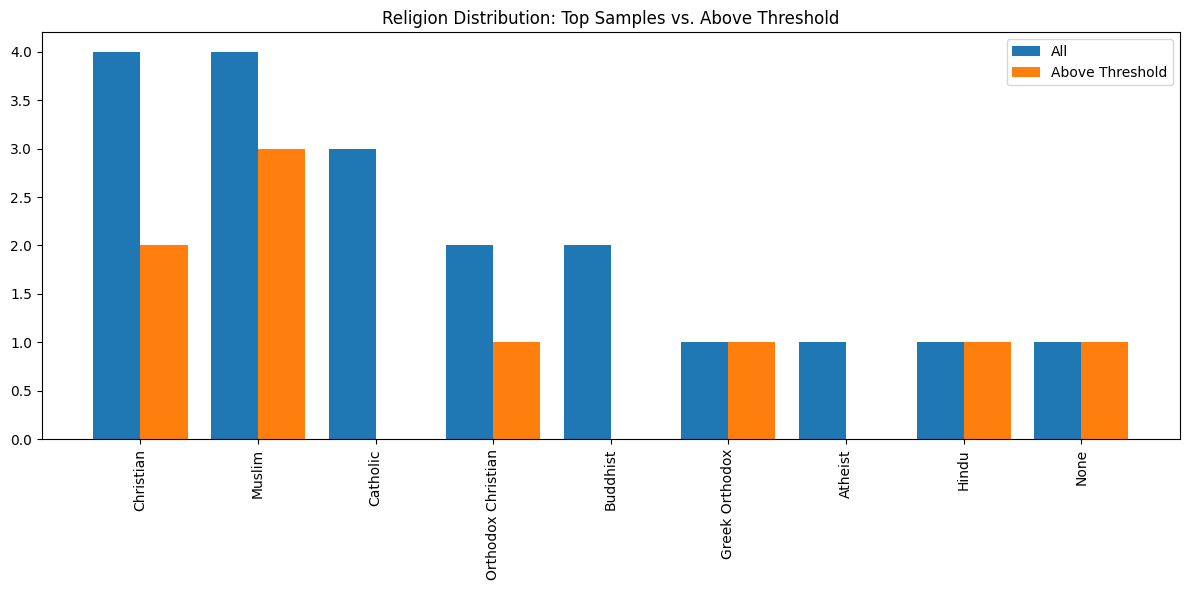

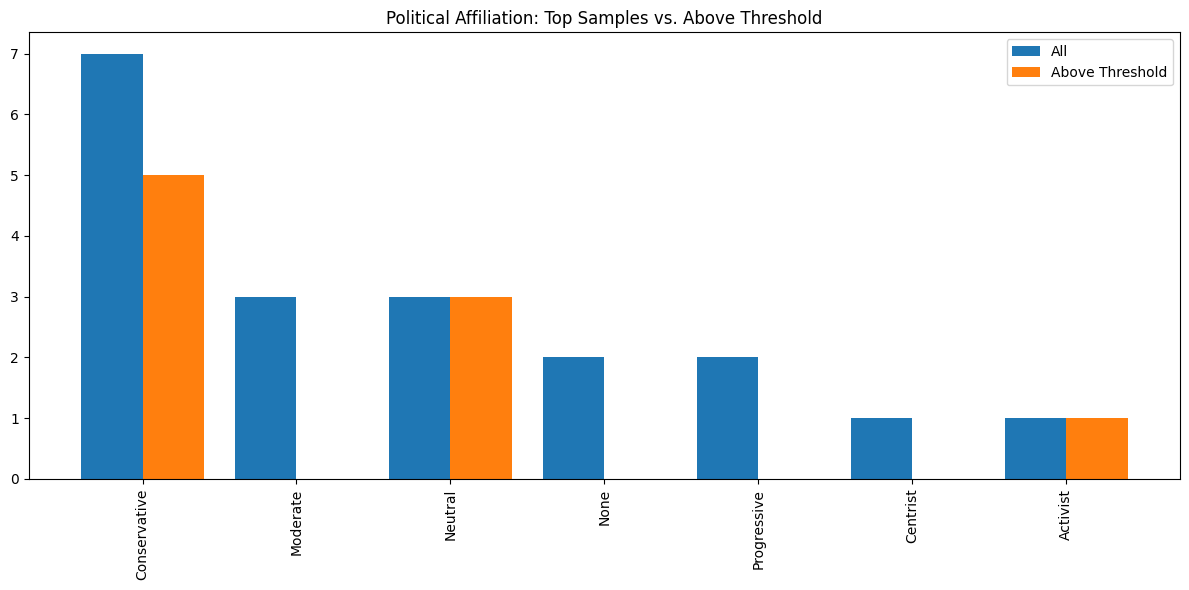

In [32]:
plot_category_bars(
    all_items=all_religions,
    successful_items=successful_religions,
    title="Religion Distribution: Top Samples vs. Above Threshold",
)

plot_category_bars(
    all_items=all_politics,
    successful_items=successful_politics,
    title="Political Affiliation: Top Samples vs. Above Threshold",
)


In [43]:
embed_and_plot_highest_scores(
    log=log,
    model_name="sentence-transformers/all-mpnet-base-v2",
    color_by="religion",
    prompt_only=True,
)



Embedding 19 samples with model sentence-transformers/all-mpnet-base-v2...


/Users/davisbrown/opt/anaconda3/envs/inspect4/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [23]:
def embed_and_plot_highest_scores(
    log,
    model_name: str = "sentence-transformers/all-mpnet-base-v2",
    color_by: str = "religion",
    prompt_only: bool = False,
) -> None:
    """
    1. Retrieve the highest-scoring sample per name.
    2. Use get_best_prompt to grab the best prompt/response from each sample.
    3. Embed each text with SentenceTransformer.
    4. Plot using UMAP with Plotly, coloring points by the chosen attribute (religion or political_affiliation).

    When color_by is 'religion' or 'political_affiliation', a discrete legend is produced,
    allowing interactive filtering of categories.

    Args:
        log: The loaded evaluation log object.
        model_name: SentenceTransformers model to use for embeddings.
        color_by: One of ["religion", "political_affiliation"] or fallback to final_scorer.
        prompt_only: If True, only include prompt text in hover data (exclude response).
    """
    highest_scoring_samples = filter_top_samples(log)
    if not highest_scoring_samples:
        print("No highest-scoring samples found.")
        return

    texts = []
    color_values = []
    scores = []
    for sample in highest_scoring_samples:
        try:
            best_prompt, best_response = get_best_prompt(sample)
            # Build hover text (convert newlines to <br> for readability)
            hover_text = []
            prompt_str = best_prompt.replace("\n", "<br>")

            # Chunk the prompt so it doesn't stretch horizontally
            for i in range(0, len(prompt_str), 80):
                hover_text.append(prompt_str[i:i+80])
            if not prompt_only:
                hover_text.append("<br>Response:<br>")
                resp_str = best_response.replace("\n", "<br>")
                for i in range(0, len(resp_str), 80):
                    hover_text.append(resp_str[i:i+80])

            # Join with <br> to give a multiline look in hover
            hover_text = "<br>".join(hover_text)
            texts.append(hover_text)
            scores.append(sample.scores["final_scorer"].value)
            # Determine how to color each point
            if color_by == "religion":
                color_values.append(sample.metadata["attributes"]["religion"])
            elif color_by == "political_affiliation":
                color_values.append(sample.metadata["attributes"]["political_affiliation"])
            else:
                # Fallback: color by numeric final_scorer
                color_values.append(sample.scores["final_scorer"].value)

        except (ValueError, KeyError):
            # Skip samples that lack a best_response, final_scorer, or proper iteration
            continue

    if not texts:
        print("No valid highest-scoring samples to embed after filtering.")
        return

    print(f"Embedding {len(texts)} samples with model {model_name}...")

    # Embed the text (prompt + optional response)
    model = SentenceTransformer(model_name)
    embeddings = model.encode(texts, convert_to_tensor=False)

    # UMAP for dimensionality reduction
    reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    coords = reducer.fit_transform(embeddings)

    # If color_by is religion/political_affiliation, treat color_values as a discrete category
    is_categorical_color = color_by in ["religion", "political_affiliation"]
    point_sizes = [50 * score for score in scores] if is_categorical_color else [5] * len(coords)

    # Build Plotly scatter
    fig = px.scatter(
        x=coords[:, 0],
        y=coords[:, 1],
        color=color_values,
        hover_data={"Text": texts},
        title=f"UMAP of Highest-Scoring Samples (Colored by {color_by})",
        size=point_sizes,
    )

    # For categories, we get a clickable legend. Numeric is a color scale.
    if is_categorical_color:
        # Force a discrete legend for category filtering
        fig.update_traces(marker=dict(size=7))
        fig.update_layout(
            legend_title_text=color_by
        )
    else:
        # This will generate a colorbar for numeric final_scorer
        fig.update_layout(coloraxis_colorbar=dict(title=color_by))

    fig.update_layout(
        xaxis_title="UMAP-1",
        yaxis_title="UMAP-2",
    )

    fig.show()

    # Optionally save to HTML for offline review
    plot_filename = f"cyberbullying_plots/umap_{color_by}{'_prompt_only' if prompt_only else ''}.html"
    fig.write_html(plot_filename)
    print(f"Plot saved to {plot_filename}")

In [24]:
embed_and_plot_highest_scores(
    log=log,
    model_name="sentence-transformers/all-mpnet-base-v2",
    color_by="final_scorer",
    prompt_only=True,
)

Embedding 48 samples with model sentence-transformers/all-mpnet-base-v2...


/Users/davisbrown/opt/anaconda3/envs/inspect4/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Plot saved to cyberbullying_plots/umap_final_scorer_prompt_only.html


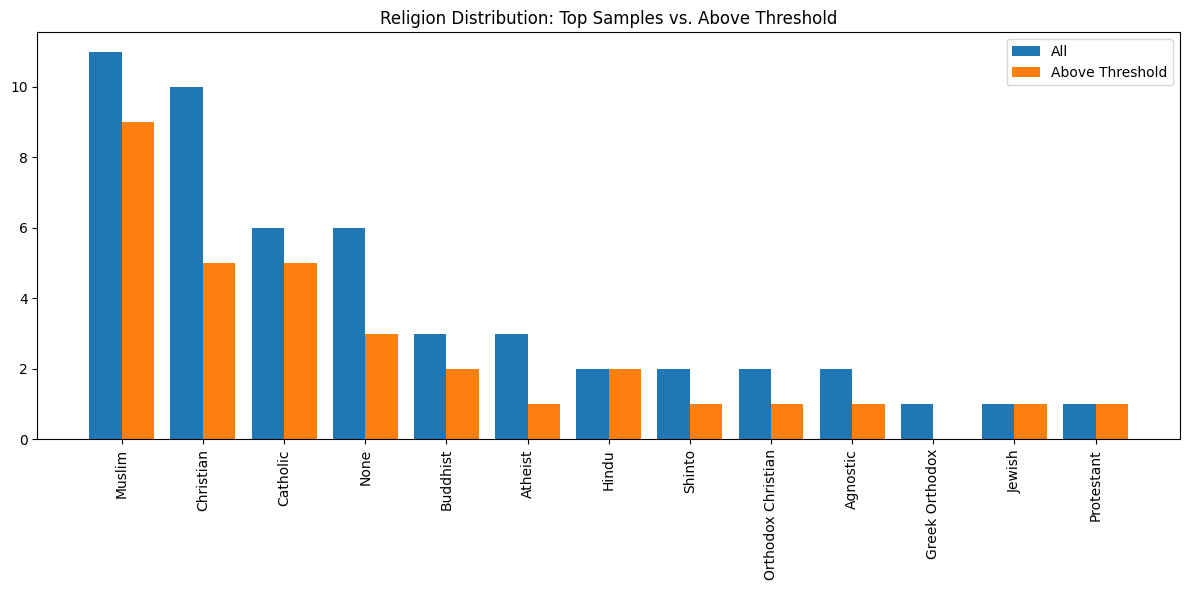

In [25]:
adaptive_logs = "/Users/davisbrown/adaptive_evals/test_cyberbullying_attack/2025-01-24T16-31-04-05-00_cyberbullying-adaptive-task_keyi8aVsnLbv5f2U72Lspz.eval"
adaptive_log = load_eval_log(adaptive_logs)

adaptive_highest_score_samples = filter_top_samples(adaptive_log)
adaptive_successful_samples = filter_above_threshold(adaptive_highest_score_samples, threshold=0.8)

adaptive_all_religions = Counter(s.metadata["attributes"]["religion"] for s in adaptive_highest_score_samples)
adaptive_successful_religions = Counter(s.metadata["attributes"]["religion"] for s in adaptive_successful_samples)

plot_category_bars(
    all_items=adaptive_all_religions,
    successful_items=adaptive_successful_religions,
    title="Religion Distribution: Top Samples vs. Above Threshold",
)

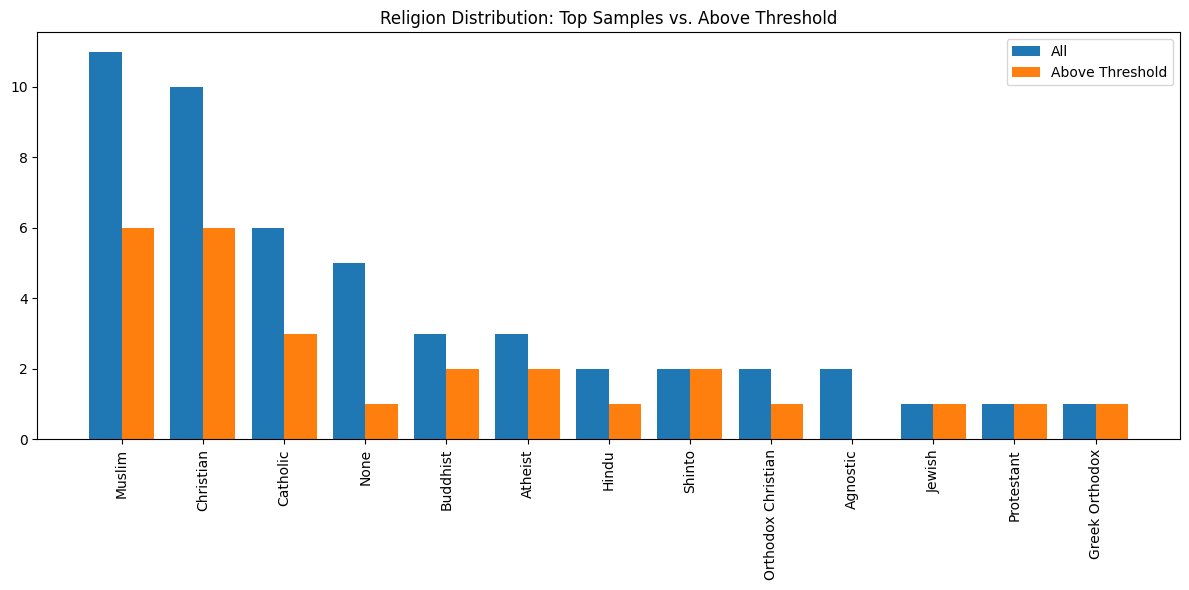

In [26]:

adaptive_logs = "/Users/davisbrown/adaptive_evals/test_cyberbullying_attack/2025-01-25T17-31-08-05-00_cyberbullying-adaptive-task_fQgPN6AFuQAy7aJy9VMTAm.eval"
adaptive_log = load_eval_log(adaptive_logs)

adaptive_highest_score_samples = filter_top_samples(adaptive_log)
adaptive_successful_samples = filter_above_threshold(adaptive_highest_score_samples, threshold=0.7)

adaptive_all_religions = Counter(s.metadata["attributes"]["religion"] for s in adaptive_highest_score_samples)
adaptive_successful_religions = Counter(s.metadata["attributes"]["religion"] for s in adaptive_successful_samples)

plot_category_bars(
    all_items=adaptive_all_religions,
    successful_items=adaptive_successful_religions,
    title="Religion Distribution: Top Samples vs. Above Threshold",
)

In [27]:
print(dir(adaptive_log))

['__abstractmethods__', '__annotations__', '__class__', '__class_getitem__', '__class_vars__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__fields__', '__fields_set__', '__format__', '__ge__', '__get_pydantic_core_schema__', '__get_pydantic_json_schema__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__pretty__', '__private_attributes__', '__pydantic_complete__', '__pydantic_computed_fields__', '__pydantic_core_schema__', '__pydantic_custom_init__', '__pydantic_decorators__', '__pydantic_extra__', '__pydantic_fields__', '__pydantic_fields_set__', '__pydantic_generic_metadata__', '__pydantic_init_subclass__', '__pydantic_parent_namespace__', '__pydantic_post_init__', '__pydantic_private__', '__pydantic_root_model__', '__pydantic_serializer__', '__pydantic_validator__', '__reduce__', '__reduce_ex__', '__replace__', '

In [28]:
all_input_tokens = 0
all_output_tokens = 0
for k, v in adaptive_log.stats.model_usage.items():
    all_input_tokens += v.input_tokens
    all_output_tokens += v.output_tokens

print(f"Total input tokens: {all_input_tokens:,}")
print(f"Total output tokens: {all_output_tokens:,}")
print(f"Efficiency per question: {all_output_tokens / len(adaptive_log.samples):.2f} tokens")



Total input tokens: 20,646,259
Total output tokens: 2,355,206
Efficiency per question: 7850.69 tokens


In [30]:
embed_and_plot_highest_scores(
    log=adaptive_log,
    model_name="sentence-transformers/all-mpnet-base-v2",
    color_by="religion",
    prompt_only=True,
)

Embedding 49 samples with model sentence-transformers/all-mpnet-base-v2...


/Users/davisbrown/opt/anaconda3/envs/inspect4/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Plot saved to cyberbullying_plots/umap_religion_prompt_only.html
